# Comparison
In this notebook we compare the ROMs we learned in the previous notebooks.

## Imports

In [1]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.patches import Rectangle
import pickle
import seaborn as sns
import pandas as pd

import time
tStart_notebook = time.time()

import sys
sys.path.insert(0, '../../../source')
sys.path.insert(0, '../../../source/fom')

%load_ext autoreload
%autoreload 2

import opinf as opinf
from fom.FomCubicHeatFEniCSx import FomCubicHeat
from polyrom.PolyRomIntrusiveTime import PolyRomIntrusiveTime
from matrixSetup.FoodTime import FoodTime
from opinf_schemes.NestedOpInf import NestedOpInf as NestedOpInf

## User settings

In [2]:
training_path = "/storage/nicole/git-save-data/opinf/cubic-heat/paper/"

scalings = [1, 1.00001, 1.0001, 1.001, 1.01, 1.1, 2, 10]
n_delta = len(scalings)

## Setup

### test data

In [3]:
with open("/storage/nicole/git-save-data/opinf/cubic-heat/paper/data/trainingdata", "rb") as file:
    Xi_test, U_para_test, compute_time_fom = pickle.load(file)

### FOM

In [4]:
nFE = U_para_test[0].shape[0]
grid_t = np.arange(0, 1+0.001, 0.001)

fom = FomCubicHeat(nFE, grid_t)
fom.timestepping = "CN"

### Reduced space

In [5]:
with open(training_path + "training", "rb") as file:
        Xi_train, U_train, VR, transformer, grid_t_train, U_para, final_training_time = pickle.load(file)

# get the shapes
nFE = VR.shape[0]
nRB = VR.shape[1]
n_para = Xi_train.shape[0]
K_train = grid_t_train.shape[0]

# set up the matrix handler
matrixhandler = FoodTime(VR, fom, transformer=transformer, Xi_train = Xi_train) # FD time derivative

## Reduced models

In [6]:
n_models = 2 + n_delta
ROMq = np.zeros((nRB, n_models), dtype=object)
names = np.zeros(n_models+1, dtype=object)
names[-1] = "projection"

### Intrusive ROM

In [7]:
names[0] = "intrusive" 

for n in range(nRB):
    ROMq[n, 0] = PolyRomIntrusiveTime(VR[:, :n+1], fom, transformer=transformer)
    ROMq[n, 0].decompose()

### Regularized OpInf
We use the ROM that was trained specifically for `r=5`

In [8]:
# with open(training_path + "trained_regularized/trained_regularized_n5_s1_test51", "rb") as file:
#     qInferred, training_path_loaded, condition_no_reg, training_time_reg, __, __ = pickle.load(file)

# if training_path_loaded != training_path + "training":
#     raise RuntimeError("Model trained on wrong training data")

# i_model = 1
# names[i_model] = "regularized OpInf"

# for n in range(nRB):
#     inferred_sub = matrixhandler.blow_down(big_matrix=qInferred[-1], nRB=nRB, indices=[*range(n+1)])
#     ROMq[n, i_model] = matrixhandler.get_reduced_model(A_new = inferred_sub, 
#                                                 indices = [*range(n+1)], 
#                                                 indices_testspace = [*range(n+1)])
    
# print("training time:", training_time_reg)

In [9]:
i_model = 1
names[i_model] = "regularized OpInf"

for n in range(nRB):

    with open(training_path + f"trained_regularized/trained_regularized_n{n+1}_s1_test51", "rb") as file:
        qInferred, training_path_loaded, condition_no_reg, training_time_reg, __, __ = pickle.load(file)

    if training_path_loaded != training_path + "training":
        raise RuntimeError("Model trained on wrong training data")

    # inferred_sub = matrixhandler.blow_down(big_matrix=qInferred[-1], nRB=nRB, indices=[*range(n+1)])
    ROMq[n, i_model] = matrixhandler.get_reduced_model(A_new = qInferred[-1], 
                                                indices = [*range(n+1)], 
                                                indices_testspace = [*range(n+1)])
    
print("training time:", training_time_reg)

training time: 52.70863223075867


### Nested OpInf

Again, we have two choices. We first load the model that was trained for r=5 and take its Galerkin projection onto the smaller reduced subspaces. Then we also look at the ROMs we got as in-between steps during the learing process.

In [10]:
for i_model, scaling in enumerate(scalings):
    names[2+i_model] = "nested OpInf"

    with open(training_path + f"trained_nested_comparison/s{scaling}/trained_nested_n5_i5_s{scaling}_test6", "rb") as file:
        qInferred, training_path_loaded, condition_no_nest, training_time_nest, __, __ = pickle.load(file)

    if training_path_loaded != training_path + "training":
        raise RuntimeError("Model trained on wrong training data")

    for n in range(nRB):
        #inferred_sub = matrixhandler.blow_down(big_matrix=qInferred[-1], nRB=nRB, indices=[*range(n+1)])
        inferred_sub = qInferred[n]
        ROMq[n, 2+i_model] = matrixhandler.get_reduced_model(A_new = inferred_sub, 
                                                    indices = [*range(n+1)], 
                                                    indices_testspace = [*range(n+1)])

    print("training time:", sum(training_time_nest))

training time: 48.21220254898071
training time: 43.53662824630737
training time: 39.13109302520752
training time: 40.928064584732056
training time: 37.555076122283936
training time: 66.04797697067261
training time: 120.70369243621826
training time: 38.47520422935486


In [11]:
names

array(['intrusive', 'regularized OpInf', 'nested OpInf', 'nested OpInf',
       'nested OpInf', 'nested OpInf', 'nested OpInf', 'nested OpInf',
       'nested OpInf', 'nested OpInf', 'projection'], dtype=object)

## Comparison -- all parameters

In [12]:
errors = np.zeros((201, n_models+1, nRB, grid_t.shape[0]))
test_time = np.zeros((201, n_models, nRB))

for i_test in range(201):

    # initialization
    U_test = U_para_test[i_test]
    para_test = Xi_test[i_test, :]
    print("test parameter:", para_test)

    for n in [4]:

        # ROM
        for i in range(n_models):
            tStart = time.time()
            sol_RB = ROMq[n, i].solve_ivp(grid_t = grid_t, para = para_test)
            test_time[i_test, i, n] = time.time()-tStart

            Sol_RB = ROMq[n, i].toFO(sol_RB)
            errors[i_test, i, n, :] = fom.norm_over_time(Sol_RB - U_test, axis = 0)

        # projection
        i = -1
        if transformer is None:
            proj = VR[:, :n+1].T @ fom.M @ U_test
        else:
            proj = VR[:, :n+1].T @ fom.M @ transformer.transform(U_test)
        Proj = ROMq[n,0].toFO(proj) 
        errors[i_test, i, n, :] = fom.norm_over_time(Proj - U_test, axis = 0)

test parameter: [0.001]
test parameter: [0.00102329]
test parameter: [0.00104713]
test parameter: [0.00107152]
test parameter: [0.00109648]
test parameter: [0.00112202]
test parameter: [0.00114815]
test parameter: [0.0011749]
test parameter: [0.00120226]
test parameter: [0.00123027]
test parameter: [0.00125893]
test parameter: [0.00128825]
test parameter: [0.00131826]
test parameter: [0.00134896]
test parameter: [0.00138038]
test parameter: [0.00141254]
test parameter: [0.00144544]
test parameter: [0.00147911]
test parameter: [0.00151356]
test parameter: [0.00154882]
test parameter: [0.00158489]
test parameter: [0.00162181]
test parameter: [0.00165959]
test parameter: [0.00169824]
test parameter: [0.0017378]
test parameter: [0.00177828]
test parameter: [0.0018197]
test parameter: [0.00186209]
test parameter: [0.00190546]
test parameter: [0.00194984]
test parameter: [0.00199526]
test parameter: [0.00204174]
test parameter: [0.0020893]
test parameter: [0.00213796]
test parameter: [0.0021

In [13]:
reference_norm = np.zeros((201, grid_t.shape[0]))
for i in range(201):
    reference_norm[i, :] = fom.norm_over_time(U_para_test[i])

In [14]:
train_error = np.zeros((n_models, 201))
test_error = np.zeros((n_models, 201))
n=4

for i_test in range(201):
    for i_model in range(n_models):
        # a = errors[i_test, i_model, n, :K_train]**2
        # train_error[i_model, i_test] = np.sqrt(grid_t[1] * sum(a))

        # a = errors[i_test, i_model, n, K_train:]**2
        # test_error[i_model, i_test] = np.sqrt(grid_t[1] * sum(a))

        train_error[i_model, i_test] = errors[i_test, i_model, n, K_train-1]
        test_error[i_model, i_test] = errors[i_test, i_model, n, -1]

In [56]:
K_train-1

200

In [65]:
relative_error_at_time_02.shape

(201, 11)

In [ ]:
error_at_time_02 = errors[:, :, 4, :K_train] # parameter x model x dimension 
error_at_time_10 = errors[:, :, 4, ]

# relative_error_at_time_02 = np.zeros(error_at_time_02.shape)
# relative_error_at_time_10 = np.zeros(error_at_time_10.shape)

relative_error_at_time_02 = (error_at_time_02.T / reference_norm[:, K_train-1]) # parameter x model x dimension 
relative_error_at_time_10 = (error_at_time_10.T / reference_norm[:, -1])

In [62]:
errors.shape

(201, 11, 5, 1001)

In [28]:
scalings

[1, 1.00001, 1.0001, 1.001, 1.01, 1.1, 2, 10]

In [29]:
sub = [0, 3, 4, 5, 6, 7]

array([0.e+00, 1.e-03, 1.e-02, 1.e-01, 1.e+00, 9.e+00])

<Axes: >

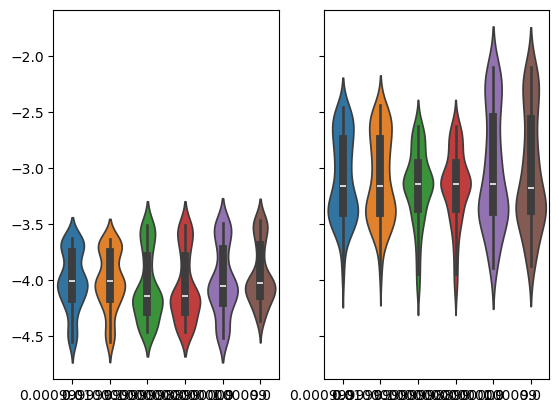

In [45]:
fig, axs = plt.subplots(1, 2, sharey = True)

data = pd.DataFrame(np.log10(train_error[2:, :][sub, :].T), columns = np.array(scalings)[sub]-1)
sns.violinplot(data, ax=axs[0])

data = pd.DataFrame(np.log10(test_error[2:, :][sub, :].T), columns = np.array(scalings)[sub]-1)
sns.violinplot(data, ax=axs[1])

In [78]:
relative_error_at_time_02.shape

(201, 11)

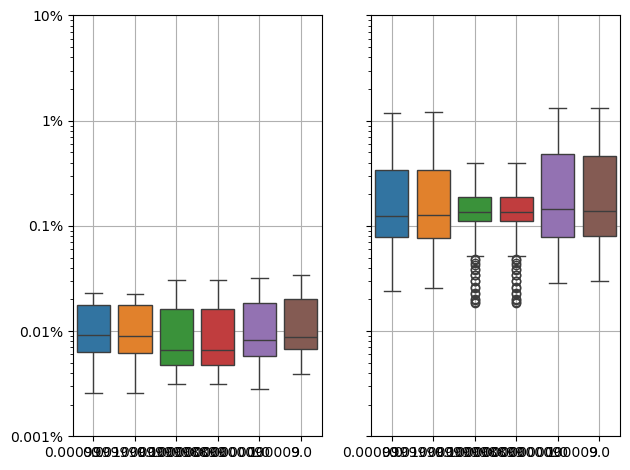

In [90]:
fig, axs = plt.subplots(1, 2, sharey = True, sharex=True)

data = pd.DataFrame((100*relative_error_at_time_02[2:, :][sub, :].T), columns = np.array(scalings)[sub]-1)
sns.boxplot(data, ax=axs[0], log_scale=True)

data = pd.DataFrame((100*relative_error_at_time_10[2:, :][sub, :].T), columns = np.array(scalings)[sub]-1)
sns.boxplot(data, ax=axs[1])

axs[0].grid(True)


axs[0].set_yticks([1e-3, 1e-2, 1e-1, 1, 10, 100], ["0.001%", "0.01%", "0.1%", "1%", "10%", "100%"])
axs[0].set_ylim(1e-3, 10)
# axs[0].set_xticklabels([0, 1], [0, "$10^{-3}$"])
# axs[0].set_yscale("log")

axs[1].grid(True)

fig.tight_layout()

In [152]:
i = 9
print(names[i], scalings[i-2]-1)
print("training time, training parameters")
reconstruction = 100 * errors[[0, 100, 200], i, 4, :201] / reference_norm[[0, 100, 200], :201]
# print(f"average error (%): {np.mean(reconstruction):.3f}")
print(f"maximum error (%):  {np.max(reconstruction):.3f}")

print("\n training time, all parameters")
reconstruction = 100 * errors[:, i, 4, :201] / reference_norm[:, :201]
# print(f"average error (%): {np.mean(reconstruction):.3f}")
print(f"maximum error (%):  {np.max(reconstruction):.3f}")

# print("\n all time, training parameters")
# reconstruction = 100 * errors[[0, 100, 200], i, 4, :] / reference_norm[[0, 100, 200], :]
# # print(f"average error (%): {np.mean(reconstruction):.3f}")
# print(f"maximum error (%):  {np.max(reconstruction):.3f}")

print("\n all time, all parameters")
reconstruction = 100 * errors[:, i, 4, :] / reference_norm[:, :]
# print(f"average error (%): {np.mean(reconstruction):.3f}")
print(f"maximum error (%):  {np.max(reconstruction):.3f}")

nested OpInf 9
training time, training parameters
maximum error (%):  0.009

 training time, all parameters
maximum error (%):  0.034

 all time, all parameters
maximum error (%):  1.311


In [148]:
scalings[5-2]

1.001

In [94]:
for i in sub:
    print(scalings[i]-1, np.max(relative_error_at_time_02[2+i, :]), np.max(relative_error_at_time_10[2+i, :]))

0 0.00022990359390360598 0.011746599340503887
0.0009999999999998899 0.0002233308654411316 0.012209765820481194
0.010000000000000009 0.0003049498920952337 0.0039667171784317804
0.10000000000000009 0.0003049498920952337 0.0039667171784317804
1 0.00031924977809862266 0.013213318853037634
9 0.0003380334060679815 0.013108211851691113


In [99]:
100 * np.max(relative_error_at_time_02[2:, :][sub, :][:, [0, 100, 200]], axis = 1)

array([0.00774991, 0.00775005, 0.00785461, 0.00785461, 0.00859776,
       0.00887029])

In [ ]:
a = 100 * np.max(relative_error_at_time_02[2:, :][sub, :], axis = 1)
print([f"{a[j]:.3} " for j in range(a.shape[0])])

['0.023 &', '0.0223 &', '0.0305 &', '0.0305 &', '0.0319 &', '0.0338 &']


In [108]:
j

NameError: name 'j' is not defined

In [100]:
100 * np.max(relative_error_at_time_10[2:, :][sub, :][:, [0, 100, 200]], axis = 1)

array([1.17465993, 1.22097658, 0.39667172, 0.39667172, 1.32133189,
       1.31082119])

In [104]:
100 * np.max(relative_error_at_time_10[2:, :][sub, :], axis = 1)

array([1.17465993, 1.22097658, 0.39667172, 0.39667172, 1.32133189,
       1.31082119])

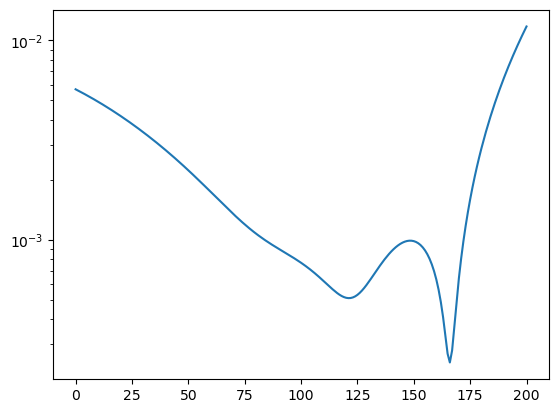

In [103]:
plt.semilogy(relative_error_at_time_10[2, :])

In [98]:
100 * np.max(relative_error_at_time_10[2:, :][sub, :], axis = 1)

array([1.17465993, 1.22097658, 0.39667172, 0.39667172, 1.32133189,
       1.31082119])

In [23]:
print("mean:", np.mean(train_error[2:, :], axis=1))
print("max:", np.max(train_error[2:, :], axis=1))

mean: [0.0001186  0.0001186  0.00011852 0.00011683 0.0001147  0.0001147
 0.0001281  0.00014109]
max: [0.00023949 0.00023949 0.0002393  0.00023276 0.00031004 0.00031004
 0.00032689 0.00034656]


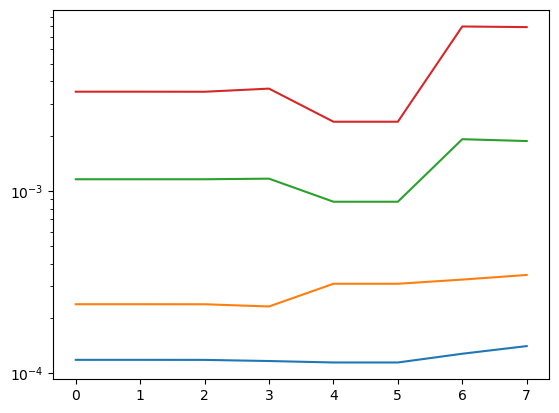

In [27]:
fig, ax = plt.subplots(1, 1)

ax.semilogy(np.mean(train_error[2:, :], axis=1), label = "mean, train")
ax.semilogy(np.max(train_error[2:, :], axis=1), label = "max, train")

ax.semilogy(np.mean(test_error[2:, :], axis=1), label = "mean, test")
ax.semilogy(np.max(test_error[2:, :], axis=1), label = "max, test")

In [20]:
test_error[2:, :].shape

(8, 201)

In [16]:
scalings

[1, 1.00001, 1.0001, 1.001, 1.01, 1.1, 2, 10]

In [17]:
test_error[:, 0]

array([0.00030426, 0.00715342, 0.00344495, 0.00344495, 0.00344595,
       0.00341427, 0.00240221, 0.00240221, 0.00800187, 0.00793822])

In [18]:
errors[i_test, i_model, n, :].shape

(1001,)

In [19]:
grid_t[]

SyntaxError: invalid syntax (2418284405.py, line 1)

In [ ]:
please stop here

Text(0, 0.5, 'relative error')

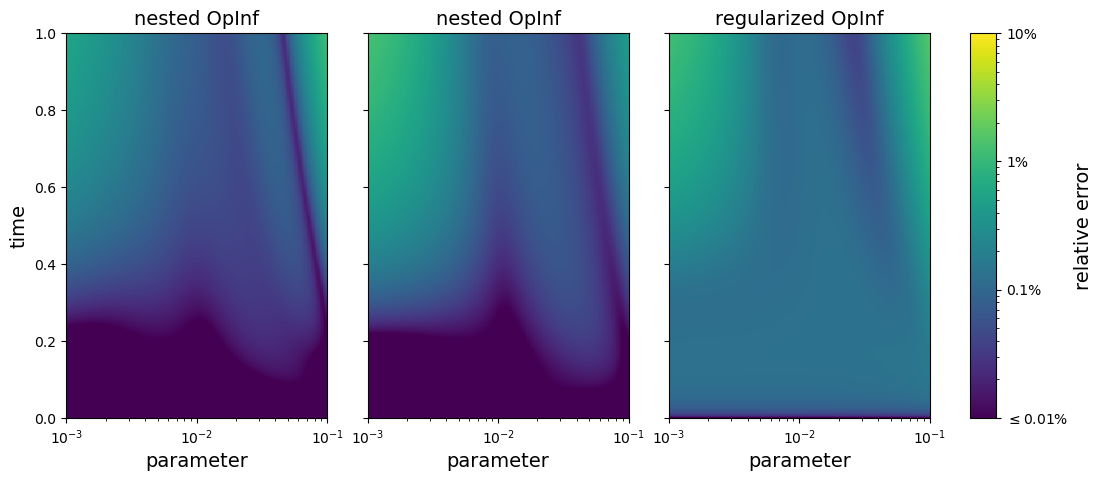

In [ ]:
# relative error
n = 4

fig, axs = plt.subplots(1, 4, figsize=(12, 5), width_ratios=[1, 1, 1, 0.1])
fontsize = 14

X, Y = np.meshgrid(Xi_test, grid_t)

for i, i_model in enumerate([3, 2, 1]):
    cs = axs[i].pcolormesh(X, Y, 100 * errors[:, i_model, n, :].T /reference_norm.T, norm = colors.LogNorm(), cmap=plt.colormaps["viridis"])
    cs.set_clim(vmin=1e-2, vmax=10)

    axs[i].set_xscale("log")
    axs[i].set_xlim(Xi_test[0, 0], Xi_test[-1, 0])
    axs[i].set_ylim(grid_t[0], grid_t[-1])
    axs[i].set_title(names[i_model], fontsize = fontsize)
    axs[i].set_xlabel("parameter", fontsize = fontsize)
    
axs[0].set_ylabel("time", fontsize=fontsize)
axs[1].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1], ["", "", "", "", "", ""])
axs[2].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1], ["", "", "", "", "", ""])

cbar = fig.colorbar(cs, cax=axs[-1])
cbar.ax.set_yticks([0.01, 0.1, 1, 10], ["$\leq$0.01%", "0.1%", "1%", "10%"])
cbar.ax.set_ylabel("relative error", fontsize = fontsize)

# fig.savefig(f"/storage/nicole/git-save-data/opinf/cubic-heat/paper/plots/error2D_rel_n{n+1}_proj.png", bbox_inches = "tight")

Text(0, 0.5, 'relative error')

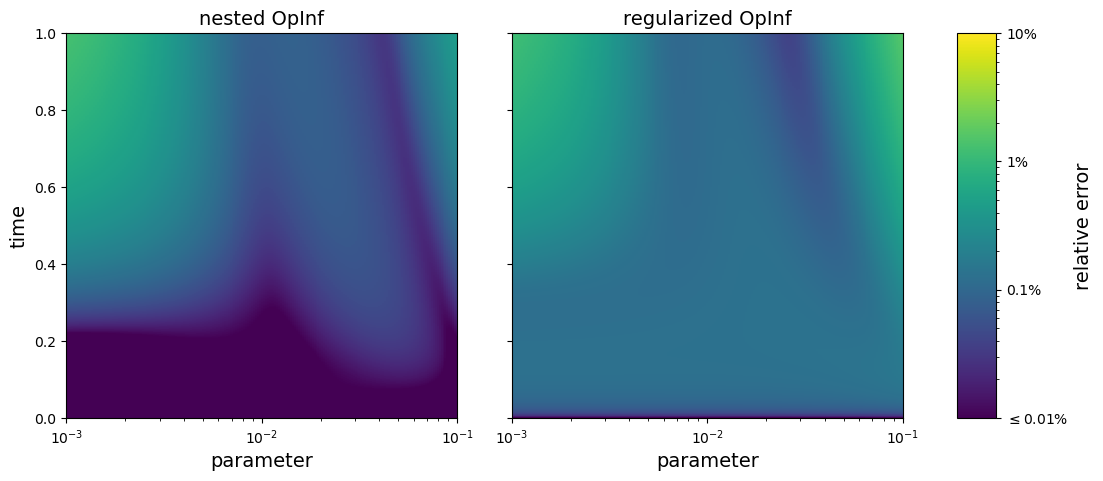

In [ ]:
# relative error
n = 4

fig, axs = plt.subplots(1, 3, figsize=(12, 5), width_ratios=[1, 1, 0.1])
fontsize = 14

X, Y = np.meshgrid(Xi_test, grid_t)

for i, i_model in enumerate([2, 1]):
    cs = axs[i].pcolormesh(X, Y, 100 * errors[:, i_model, n, :].T /reference_norm.T, norm = colors.LogNorm(), cmap=plt.colormaps["viridis"])
    cs.set_clim(vmin=1e-2, vmax=10)

    axs[i].set_xscale("log")
    axs[i].set_xlim(Xi_test[0, 0], Xi_test[-1, 0])
    axs[i].set_ylim(grid_t[0], grid_t[-1])
    axs[i].set_title(names[i_model], fontsize = fontsize)
    axs[i].set_xlabel("parameter", fontsize = fontsize)
    
axs[0].set_ylabel("time", fontsize=fontsize)
axs[1].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1], ["", "", "", "", "", ""])
axs[2].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1], ["", "", "", "", "", ""])

cbar = fig.colorbar(cs, cax=axs[-1])
cbar.ax.set_yticks([0.01, 0.1, 1, 10], ["$\leq$0.01%", "0.1%", "1%", "10%"])
cbar.ax.set_ylabel("relative error", fontsize = fontsize)

# fig.savefig(f"/storage/nicole/git-save-data/opinf/cubic-heat/paper/plots/error2D_rel_n{n+1}_opinf.png", bbox_inches = "tight")

In [ ]:
names[1] = "standard OpInf"

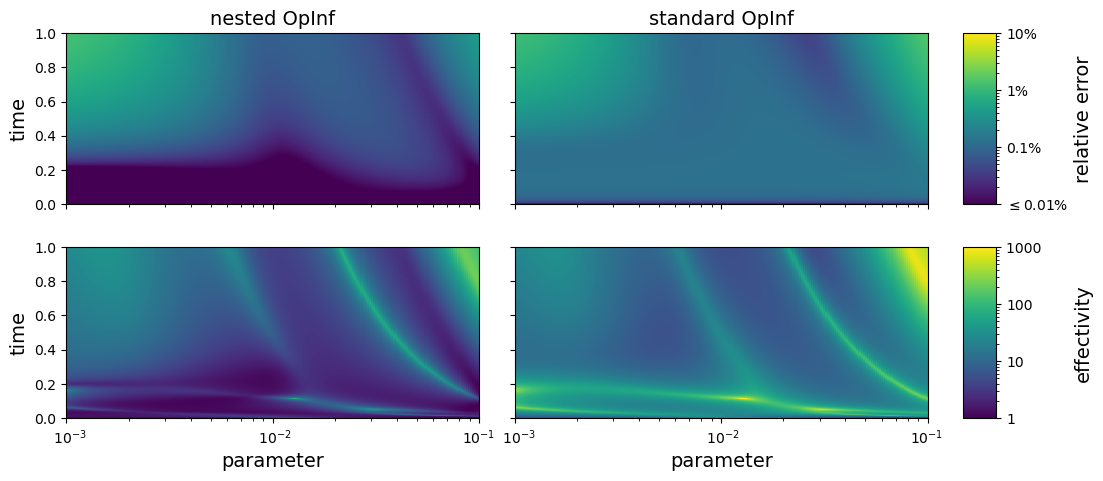

In [ ]:
# effectivity
n = 4

fig, axs = plt.subplots(2, 3, figsize=(12, 5), width_ratios=[1, 1, 0.08])
fontsize = 14

X, Y = np.meshgrid(Xi_test, grid_t)

# error
for i, i_model in enumerate([2, 1]):
    cs0 = axs[0, i].pcolormesh(X, Y, 100 * errors[:, i_model, n, :].T /reference_norm.T, norm = colors.LogNorm(), cmap=plt.colormaps["viridis"])
    cs0.set_clim(vmin=1e-2, vmax=10)

    axs[0, i].set_xscale("log")
    axs[0, i].set_xlim(Xi_test[0, 0], Xi_test[-1, 0])
    axs[0, i].set_ylim(grid_t[0], grid_t[-1])
    axs[0, i].set_title(names[i_model], fontsize = fontsize)
    axs[0, i].set_xticklabels(["", "", ""])

# effectivity
for i, i_model in enumerate([2, 1]):
    cs = axs[1, i].pcolormesh(X, Y, errors[:, i_model, n, :].T / errors[:, -1, n, :].T, norm = colors.LogNorm(), cmap=plt.colormaps["viridis"])
    cs.set_clim(vmin=1, vmax=1000)

    axs[1, i].set_xscale("log")
    axs[1, i].set_xlim(Xi_test[0, 0], Xi_test[-1, 0])
    axs[1, i].set_ylim(grid_t[0], grid_t[-1])
    axs[1, i].set_xlabel("parameter", fontsize = fontsize)
    axs[1, i].set_xticks([1e-3, 1e-2, 1e-1], ["  $10^{-3}$", " $10^{-2}$", "$10^{-1}$ "])

axs[0, 0].set_ylabel("time", fontsize=fontsize)
axs[0, 1].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1], ["", "", "", "", "", ""])
axs[0, 2].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1], ["", "", "", "", "", ""])
axs[1, 0].set_ylabel("time", fontsize=fontsize)
axs[1, 1].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1], ["", "", "", "", "", ""])
axs[1, 2].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1], ["", "", "", "", "", ""])

cbar = fig.colorbar(cs, cax=axs[1, -1])
cbar.ax.set_yticks([1, 10, 100, 1000], [1, 10, 100, "1000      "])
cbar.ax.set_ylabel("effectivity", fontsize = fontsize)

cbar0 = fig.colorbar(cs0, cax=axs[0, -1])
cbar0.ax.set_yticks([0.01, 0.1, 1, 10], ["$\leq$0.01%", "0.1%", "1%", "10%"])
cbar0.ax.set_ylabel("relative error", fontsize = fontsize)

fig.subplots_adjust(hspace=0.25)
fig.subplots_adjust(wspace=0.25/2)

# fig.savefig(f"/storage/nicole/git-save-data/opinf/cubic-heat/paper/plots/error2D_effectivity2D_n{n+1}_opinf.png", bbox_inches = "tight")

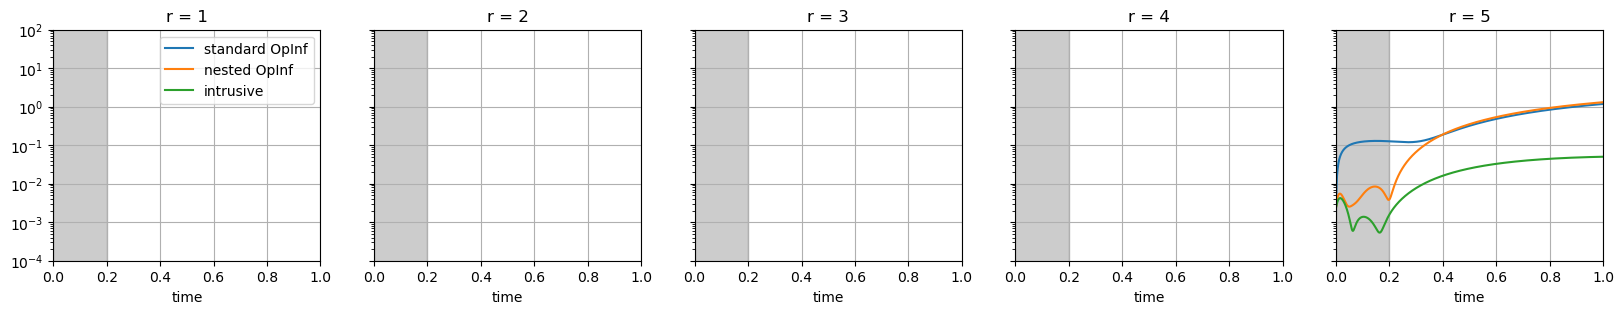

In [ ]:
i_test = 0

fig, axs = plt.subplots(1, nRB, sharey = True, sharex = True, figsize = (4*nRB, 3))

for j in range(nRB):
    rect = Rectangle((0, 1e-12), final_training_time, 200, color="k", alpha=0.2)
    axs[j].add_patch(rect)

    for i in [1, 2, 0]:
        axs[j].semilogy(grid_t, 100 * errors[i_test, i, j, :] / reference_norm[i_test, :], label = names[i])

    axs[j].set_xlabel("time")
    axs[j].set_title("r = {}".format(j + 1))
    axs[j].grid(True)

axs[0].set_ylim((1e-4, 1e+2))
axs[0].set_xlim((0, 1))
axs[0].legend()

In [ ]:
for n in range(nRB):
    print(f"Mean ROM compute time (r={n+1}):", np.mean(test_time[:, :, n], axis = 0))

Mean ROM compute time (r=1): [0. 0. 0. 0. 0. 0. 0. 0. 0.]
Mean ROM compute time (r=2): [0. 0. 0. 0. 0. 0. 0. 0. 0.]
Mean ROM compute time (r=3): [0. 0. 0. 0. 0. 0. 0. 0. 0.]
Mean ROM compute time (r=4): [0. 0. 0. 0. 0. 0. 0. 0. 0.]
Mean ROM compute time (r=5): [0.01672669 0.01531309 0.01560761 0.01730053 0.0157923  0.01585862
 0.01718526 0.01707005 0.01713978]


In [ ]:
for i in range(3):
    print(f"Mean speed-up ({names[i]})", np.mean(compute_time_fom / test_time[:, i, 4], axis = 0))

Mean speed-up (intrusive) 504.15742238917886
Mean speed-up (standard OpInf) 537.0664892442134
Mean speed-up (nested OpInf) 527.2239705268411


In [ ]:
errors.shape

(201, 10, 5, 1001)

In [ ]:
i = 3
print(names[i])
print("training time, training parameters")
reconstruction = 100 * errors[[0, 100, 200], i, 4, :201] / reference_norm[[0, 100, 200], :201]
print(f"average error (%): {np.mean(reconstruction)}")
print(f"maximum error (%):  {np.max(reconstruction)}")

print("\n all time, training parameters")
reconstruction = 100 * errors[[0, 100, 200], i, 4, :] / reference_norm[[0, 100, 200], :]
print(f"average error (%): {np.mean(reconstruction)}")
print(f"maximum error (%):  {np.max(reconstruction)}")

print("\n training time, all parameters")
reconstruction = 100 * errors[:, i, 4, :201] / reference_norm[:, :201]
print(f"average error (%): {np.mean(reconstruction)}")
print(f"maximum error (%):  {np.max(reconstruction)}")

print("\n all time, all parameters")
reconstruction = 100 * errors[:, i, 4, :] / reference_norm[:, :]
print(f"average error (%): {np.mean(reconstruction)}")
print(f"maximum error (%):  {np.max(reconstruction)}")

nested OpInf
training time, training parameters
average error (%): 0.0037697425453946357
maximum error (%):  0.007749911633768546

 all time, training parameters
average error (%): 0.1968354015154621
maximum error (%):  1.1746599340503887

 training time, all parameters
average error (%): 0.0058703773162758766
maximum error (%):  0.0229903593903606

 all time, all parameters
average error (%): 0.0882207176559123
maximum error (%):  1.1746599340503887


In [ ]:
i = 2
print(names[i])
print("training time, training parameters")
reconstruction = errors[[0, 100, 200], i, 4, :201] / errors[[0, 100, 200], -1, 4, :201]
print(f"average effectivity: {np.mean(reconstruction)}")
print(f"maximum effectivity:  {np.max(reconstruction)}")

print("\n all time, training parameters")
reconstruction = errors[[0, 100, 200], i, 4, :] / errors[[0, 100, 200], -1, 4, :]
print(f"average effectivity: {np.mean(reconstruction)}")
print(f"maximum effectivity:  {np.max(reconstruction)}")

print("\n training time, all parameters")
reconstruction = errors[:, i, 4, :201] / errors[:, -1, 4, :201]
print(f"average effectivity: {np.mean(reconstruction)}")
print(f"maximum effectivity:  {np.max(reconstruction)}")

print("\n all time, all parameters")
reconstruction = errors[:, i, 4, :] / errors[:, -1, 4, :]
print(f"average effectivity: {np.mean(reconstruction)}")
print(f"maximum effectivity:  {np.max(reconstruction)}")

nested OpInf
training time, training parameters
average effectivity: 3.3427534165821946
maximum effectivity:  22.950152050662247

 all time, training parameters
average effectivity: 26.070137338859205
maximum effectivity:  217.06503309230303

 training time, all parameters
average effectivity: 2.8779637645123812
maximum effectivity:  75.40786767731917

 all time, all parameters
average effectivity: 10.89118332395793
maximum effectivity:  217.06503309230303


### comparison for different reduced dimensions

In [ ]:
error_at_time_02 = errors[:, :, :, 200] # parameter x model x dimension 
error_at_time_10 = errors[:, :, :, 1000]

relative_error_at_time_02 = np.zeros(error_at_time_02.shape)
relative_error_at_time_10 = np.zeros(error_at_time_10.shape)

for n in range(5):
    relative_error_at_time_02[:, :, n] = (error_at_time_02[:, :, n].T / reference_norm[:, 200]).T # parameter x model x dimension 
    relative_error_at_time_10[:, :, n] = (error_at_time_10[:, :, n].T / reference_norm[:, 1000]).T

ValueError: array must not contain infs or NaNs

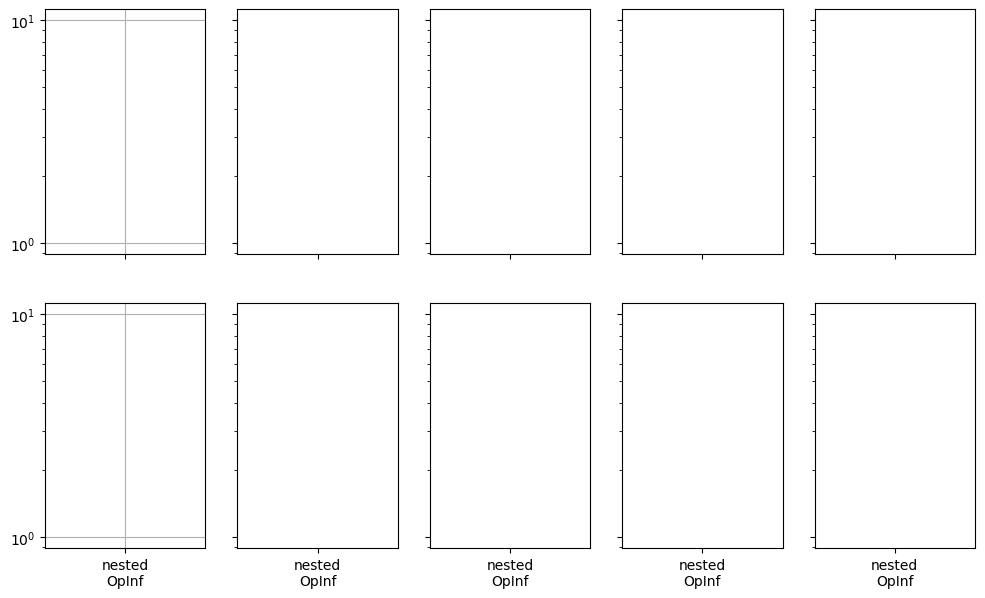

In [ ]:
fig, axs = plt.subplots(2, 5, sharex = True, sharey = True, figsize=(12, 7))
my_pal = {"nested\nOpInf": "#00a9b7", "standard\nOpInf": "#9cadb7"}

for n in range(5):

    axs[1, n].grid(True)
    axs[0, n].grid(True)

    # top row: final time 0.2
    data = pd.DataFrame(100 * relative_error_at_time_02[:, [2, 1], n], columns = ["nested\nOpInf", "standard\nOpInf"])
    sns.violinplot(data, log_scale=True, ax=axs[0, n], split=True, palette=my_pal, alpha=1, inner = None)

    
    axs[0, n].set_title(f"r = {n+1}", fontsize=fontsize)

    # bottom row: final time 1.0
    data = pd.DataFrame(100 * relative_error_at_time_10[:, [2, 1], n], columns = ["nested\nOpInf", "standard\nOpInf"])
    sns.violinplot(data, log_scale=True, ax=axs[1, n], split=True, palette=my_pal, inner = None)

    

axs[0, 0].set_ylabel("relative error \n (t=0.2)", fontsize=fontsize)
axs[0, 0].set_ylim(1e-3, 1e+2)
axs[0, 0].set_yticks([1e-3, 1e-2, 1e-1, 1, 10, 100], ["0.001%", "0.01%", "0.1%", "1%", "10%", "100%"])

axs[1, 0].set_ylabel("relative error \n (t=1.0)", fontsize=fontsize)

# fig.savefig(f"/storage/nicole/git-save-data/opinf/cubic-heat/paper/plots/error_over_dimension_trn.png", bbox_inches = "tight")

In [154]:
with open(training_path + "trained_nested/trained_nested_n5_i5", "rb") as file:
    loaded = pickle.load(file)

scaling = scalings[4]
with open(training_path + f"trained_nested_comparison/s{scaling}/trained_nested_n5_i5_s{scaling}_test6", "rb") as file:
    loaded2 = pickle.load(file)

scaling = scalings[5]
with open(training_path + f"trained_nested_comparison/s{scaling}/trained_nested_n5_i5_s{scaling}_test6", "rb") as file:
    loaded3 = pickle.load(file)

In [155]:
used = loaded[0][-1]
test = loaded2[0][-1]
test2 = loaded3[0][-1]

In [129]:
scalings

[1, 1.00001, 1.0001, 1.001, 1.01, 1.1, 2, 10]

In [132]:
la.norm(used-test)

np.float64(0.0)

In [156]:
la.norm(test-test2)

np.float64(0.0)

In [127]:
used[0, :]

array([-10.58462754,  -8.59470653,  -2.58099191,   1.11398702,
        -0.28871205])

In [128]:
test[0, :]

array([-11.20700858,  -8.28382026,  -2.90020895,   0.97428333,
        -0.31375165])

In [ ]:
fig, axs = plt.subplots(2, 5, sharex = True, sharey = False, figsize=(12, 7))



for n in range(5):

    # top row: final time 0.2
    data = pd.DataFrame(100 * relative_error_at_time_10[:, [2, 1], n], columns = ["nested\nOpInf", "regularized\nOpInf"])
    sns.violinplot(data, log_scale=True, ax=axs[0, n], split=True, palette=my_pal)

    axs[0, n].grid(True)
    axs[0, n].set_title(f"r = {n+1}", fontsize=fontsize)
    axs[0, n].set_ylim(1e-3, 1e+2)
    axs[0, n].set_yticklabels([])

    # top row: final time 0.2
    data = pd.DataFrame((relative_error_at_time_10[:, [2, 1], n].T / relative_error_at_time_10[:, -1, n]).T, columns = ["nested\nOpInf", "regularized\nOpInf"])
    sns.violinplot(data, log_scale=True, ax=axs[1, n], split=True, palette=my_pal)

    axs[1, n].grid(True)
    axs[1, n].set_title(f"r = {n+1}", fontsize=fontsize)
    axs[1, n].set_ylim(1, 1e+4)
    axs[1, n].set_yticklabels([])

axs[0, 0].set_ylabel("relative error", fontsize=fontsize)

axs[0, 0].set_yticks([1e-3, 1e-2, 1e-1, 1, 10, 100], ["0.001%", "0.01%", "0.1%", "1%", "10%", "100%"])

axs[1, 0].set_ylabel("effectivity", fontsize=fontsize)

In [ ]:
reference_norm.shape

In [ ]:
errors.shape

In [ ]:
i_test = 0

fig, axs = plt.subplots(1, nRB, sharey = True, sharex = True, figsize = (4*nRB, 3))

for j in range(nRB):
    rect = Rectangle((0, 1e-12), final_training_time, 200, color="k", alpha=0.2)
    axs[j].add_patch(rect)

    for i in [1, 2, 0]:
        axs[j].semilogy(grid_t, 100 * errors[i_test, i, j, :] / reference_norm[i_test, :], label = names[i])

    axs[j].set_xlabel("time")
    axs[j].set_title("r = {}".format(j + 1))
    axs[j].grid(True)

axs[0].set_ylim((1e-4, 1e+2))
axs[0].set_xlim((0, 1))
axs[0].legend()

In [157]:


with open(training_path + "trained_nested/trained_nested_n5_i5", "rb") as file:
    loaded = pickle.load(file)

with open("/storage/nicole/git-save-data/opinf/cubic-heat/revision/trained_nested/" + f"trained_nested_n5_i5_s{1.01}_test6", "rb") as file:
    loaded2 = pickle.load(file)

In [158]:
la.norm(loaded[0][4] - loaded2[0][4])

np.float64(0.0)

In [159]:
training_error_fields = loaded2[6]
chosen_regularization = loaded2[7]
chosen_minima = loaded2[8]
weights_linear = loaded2[4]
ratio_cubic = loaded2[5]

In [183]:
np.max(training_error_fields[n][:, :, :].T, axis=2)

array([[0.07222041, 0.21442994, 0.21912913, 0.2191774 ],
       [0.06418342, 0.18732946, 0.19126703, 0.19130742],
       [0.02079706, 0.0304674 , 0.03077581, 0.03077897]])

In [186]:
training_error_fields[n][:, :, 0]

array([[0.02622429, 0.02622429, 0.02622429, 0.02622424],
       [0.02622429, 0.02622429, 0.02622424, 0.02621809],
       [0.02622429, 0.02622424, 0.02621809, 0.07222279],
       [0.02622424, 0.02621809, 0.07222279, 0.21443026],
       [0.02621809, 0.07222277, 0.21443025, 0.21912913],
       [0.07222041, 0.21442994, 0.21912913, 0.2191774 ]])

In [202]:
[np.max(training_error_fields[n]) for n in range(5)]

[np.float64(0.21917739900543826),
 np.float64(0.0624457920596973),
 np.float64(0.007350866545762015),
 np.float64(0.000733188358643005),
 np.float64(0.0001232261464654072)]

In [203]:
[np.min(training_error_fields[n]) for n in range(5)]

[np.float64(0.018241547360326432),
 np.float64(0.0016983707982588026),
 np.float64(0.0003016704858137885),
 np.float64(3.701850687827014e-05),
 np.float64(1.8811293404630595e-05)]

In [220]:
fontsize = 14
import matplotlib.ticker as mticker

In [248]:
chosen_regularization[0]

[1, 3]

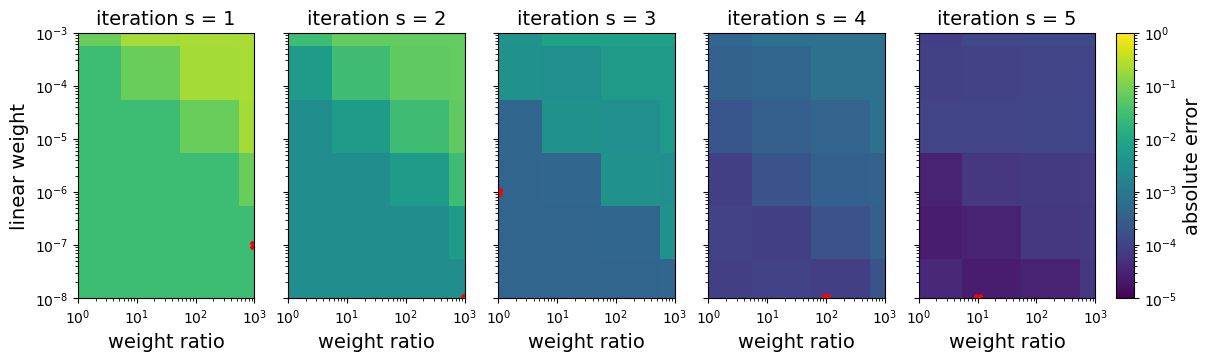

In [250]:
fig, axs = plt.subplots(1, 6, width_ratios=[1, 1, 1, 1, 1, 0.1], figsize=(12, 3.5), constrained_layout=True)

X, Y = np.meshgrid(ratio_cubic, weights_linear)

for n in range(5):
    col = n

    cs = axs[col].pcolormesh(X, Y, np.max(training_error_fields[n][:, :, :], axis=2), norm = colors.LogNorm(), cmap=plt.colormaps["viridis"])
    cs.set_clim(1e-5, 1)

    axs[col].set_xscale("log")
    axs[col].set_yscale("log")
    axs[col].set_ylim(weights_linear[0], weights_linear[-1])
    axs[col].set_xlim(ratio_cubic[0], ratio_cubic[-1])
    axs[col].set_xlabel("weight ratio", fontsize=fontsize)

    axs[col].plot(ratio_cubic[chosen_regularization[n][1]], weights_linear[chosen_regularization[n][0]], marker = "X", color = "r")

    axs[col].set_title(f"iteration s = {n+1}", fontsize = fontsize)

    if n != 0:
        axs[col].tick_params(labelleft=False)

cbar = fig.colorbar(cs, cax=axs[5])
ticks = np.logspace(-5, 0, 6)

cbar.set_ticks(ticks)
cbar.ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext())
cbar.ax.set_ylabel("absolute error", fontsize = fontsize)

axs[0].set_ylabel("linear weight", fontsize=fontsize)

fig.savefig("./plots/nested-error", bbox_inches="tight")

Text(0, 0.5, 'weight ratio')

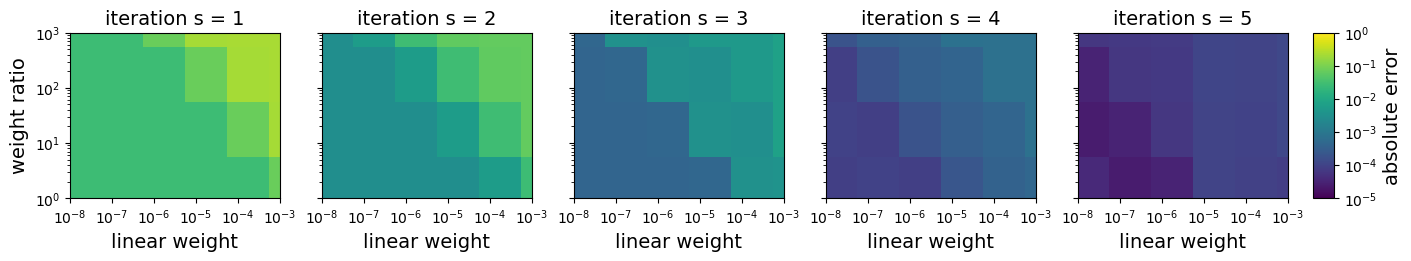

In [243]:
fig, axs = plt.subplots(1, 6, width_ratios=[1, 1, 1, 1, 1, 0.1], figsize=(14, 2.5), constrained_layout=True)

X, Y = np.meshgrid(weights_linear, ratio_cubic)

for n in range(5):
    col = n

    cs = axs[col].pcolormesh(X, Y, np.max(training_error_fields[n][:, :, :], axis=2).T, norm = colors.LogNorm(), cmap=plt.colormaps["viridis"])
    cs.set_clim(1e-5, 1)

    axs[col].set_xscale("log")
    axs[col].set_yscale("log")
    axs[col].set_xlim(weights_linear[0], weights_linear[-1])
    axs[col].set_ylim(ratio_cubic[0], ratio_cubic[-1])
    axs[col].set_xlabel("linear weight", fontsize=fontsize)

    ticks = np.logspace(-8, -3, 6)
    axs[col].set_xticks(ticks)
    axs[col].tick_params(axis='x', labelsize=fontsize - 4)

    axs[col].set_title(f"iteration s = {n+1}", fontsize = fontsize)

    if n != 0:
        axs[col].tick_params(labelleft=False)

cbar = fig.colorbar(cs, cax=axs[5])
ticks = np.logspace(-5, 0, 6)

cbar.set_ticks(ticks)
cbar.ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext())
cbar.ax.set_ylabel("absolute error", fontsize = fontsize)

axs[0].set_ylabel("weight ratio", fontsize=fontsize)

# for row in axs:
#     for ax in row[:3]:  # only first 3 columns
#         ax.set_box_aspect(1)

# plt.subplots_adjust(wspace=0.2)


# fig.tight_layout()

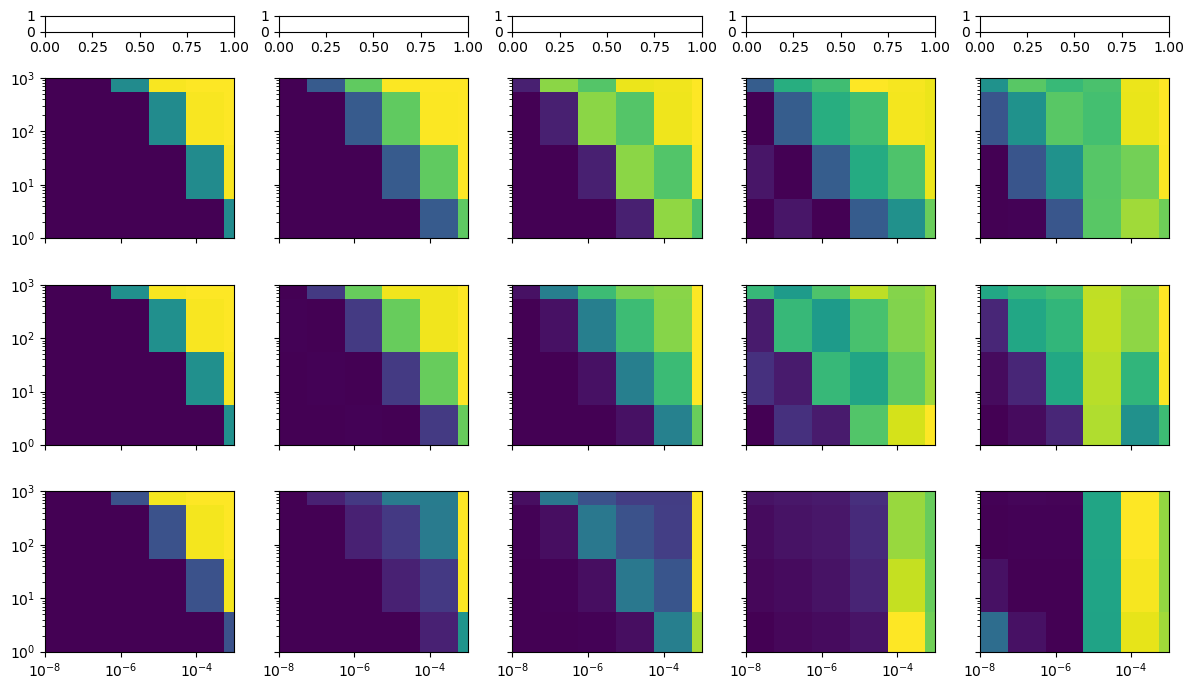

In [181]:
fig, axs = plt.subplots(4, 5, height_ratios=[0.1, 1, 1, 1], figsize=(12, 7))

X, Y = np.meshgrid(weights_linear, ratio_cubic)

for n in range(5):
    col = n
    for row in range(1, 4):

        axs[row, col].pcolormesh(X, Y, training_error_fields[n][:, :, row-1].T, norm = colors.LogNorm(), cmap=plt.colormaps["viridis"])

        axs[row, col].set_xscale("log")
        axs[row, col].set_yscale("log")
        axs[row, col].set_xlim(weights_linear[0], weights_linear[-1])
        axs[row, col].set_ylim(ratio_cubic[0], ratio_cubic[-1])

        if n != 0:
            axs[row, col].tick_params(labelleft=False)

        if row != 3:
            axs[row, col].tick_params(labelbottom=False)


# for row in axs:
#     for ax in row[:3]:  # only first 3 columns
#         ax.set_box_aspect(1)

# plt.subplots_adjust(wspace=0.05, hspace=0.05)


fig.tight_layout()

In [174]:
weights_linear

array([1.e-08, 1.e-07, 1.e-06, 1.e-05, 1.e-04, 1.e-03])

In [175]:
ratio_cubic

array([   1.,   10.,  100., 1000.])